# Backtesting and Model Comparison

Evaluate forecasting robustness using rolling 8-week recursive backtests and compare alternative feature sets.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [2]:
def find_project_root():
    path = Path.cwd().resolve()

    for candidate in [path, *path.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate

    raise FileNotFoundError("Project root not found")


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [3]:
model_data = pd.read_csv(
    PROCESSED_DIR / "store_week_features.csv"
)

model_data["Date"] = pd.to_datetime(
    model_data["Date"]
)

model_data = (
    model_data
    .sort_values(["Store", "Date"])
    .reset_index(drop=True)
)

## Dataset Validation

In [4]:
assert len(model_data) == 4095
assert model_data["Store"].nunique() == 45

assert not model_data.duplicated(
    ["Store", "Date"]
).any()

print("Rows:", len(model_data))
print("Stores:", model_data["Store"].nunique())
print(
    "Date range:",
    model_data["Date"].min().date(),
    "to",
    model_data["Date"].max().date()
)

Rows: 4095
Stores: 45
Date range: 2011-02-04 to 2012-10-26


## Evaluation Metric

In [5]:
def wape(actual, forecast):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)

    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(actual - forecast).sum()
        / denominator
    )

In [6]:
def evaluate_forecast(actual, forecast):
    return {
        "MAE": mean_absolute_error(
            actual,
            forecast
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                forecast
            )
        ),
        "WAPE": wape(
            actual,
            forecast
        )
    }

## Backtest Design

Four rolling 8-week forecast windows are evaluated before the final holdout.

| Window | Forecast Period |
|---|---|
| 1 | 2012-05-04 → 2012-06-22 |
| 2 | 2012-06-01 → 2012-07-20 |
| 3 | 2012-06-29 → 2012-08-17 |
| 4 | 2012-07-27 → 2012-09-21 |

The final holdout beginning 2012-09-28 remains untouched.

In [7]:
backtest_windows = [
    {
        "window": 1,
        "origin": pd.Timestamp("2012-04-27"),
        "start": pd.Timestamp("2012-05-04"),
        "end": pd.Timestamp("2012-06-22")
    },
    {
        "window": 2,
        "origin": pd.Timestamp("2012-05-25"),
        "start": pd.Timestamp("2012-06-01"),
        "end": pd.Timestamp("2012-07-20")
    },
    {
        "window": 3,
        "origin": pd.Timestamp("2012-06-22"),
        "start": pd.Timestamp("2012-06-29"),
        "end": pd.Timestamp("2012-08-17")
    },
    {
        "window": 4,
        "origin": pd.Timestamp("2012-07-27"),
        "start": pd.Timestamp("2012-08-03"),
        "end": pd.Timestamp("2012-09-21")
    }
]

In [8]:
for window in backtest_windows:
    dates = pd.date_range(
        window["start"],
        window["end"],
        freq="7D"
    )

    assert len(dates) == 8
    assert window["origin"] < window["start"]
    assert window["end"] < pd.Timestamp("2012-09-28")

print("Backtest windows validated.")

Backtest windows validated.


## Feature Sets

In [9]:
target = "Weekly_Sales"

core_numeric = [
    "lag_1",
    "lag_2",
    "lag_52",
    "rolling_mean_4",
    "rolling_std_4",
    "WeekOfYear",
    "Month",
    "Size"
]

core_categorical = [
    "HolidayName",
    "Type"
]

In [10]:
external_numeric = [
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment"
]

available_external = [
    col
    for col in external_numeric
    if col in model_data.columns
]

print("External features:")
print(available_external)

External features:
['Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']


### Feature Sets

**Core**

Historical sales, calendar, holiday, and store characteristics.

**Core + External**

Core features plus available economic, weather, fuel, and Markdown variables.

External missing values are handled by median imputation fitted within each training pipeline.

In [11]:
feature_sets = {
    "Core": {
        "numeric": core_numeric,
        "categorical": core_categorical,
        "external": []
    },
    "Core + External": {
        "numeric": core_numeric + available_external,
        "categorical": core_categorical,
        "external": available_external
    }
}

for name, features in feature_sets.items():
    print(
        name,
        "features:",
        len(features["numeric"])
        + len(features["categorical"])
    )

Core features: 10
Core + External features: 19


In [12]:
def build_model(numeric_features, categorical_features):
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

## Recursive Forecasting

Each backtest trains only on data available before its forecast origin.

Predictions are generated one week at a time, with previous predictions becoming available as historical inputs for later weeks.

In [13]:
def recursive_backtest_forecast(
    model,
    history,
    future_calendar,
    feature_columns
):
    history = (
        history[
            ["Store", "Date", "Weekly_Sales"]
        ]
        .copy()
        .sort_values(["Store", "Date"])
    )

    future_calendar = (
        future_calendar
        .copy()
        .sort_values(["Date", "Store"])
    )

    store_ids = sorted(
        history["Store"].unique()
    )

    predictions = []

    for date in sorted(
        future_calendar["Date"].unique()
    ):

        current_calendar = future_calendar[
            future_calendar["Date"] == date
        ].copy()

        assert len(current_calendar) == 45
        assert current_calendar["Store"].nunique() == 45

        rows = []

        for store_id in store_ids:

            store_history = (
                history[
                    history["Store"] == store_id
                ]
                .sort_values("Date")
                .reset_index(drop=True)
            )

            sales = store_history[
                "Weekly_Sales"
            ]

            assert len(sales) >= 52

            row_calendar = current_calendar[
                current_calendar["Store"] == store_id
            ].iloc[0]

            row = {
                "Store": store_id,
                "Date": date,
                "lag_1": sales.iloc[-1],
                "lag_2": sales.iloc[-2],
                "lag_52": sales.iloc[-52],
                "rolling_mean_4": sales.iloc[-4:].mean(),
                "rolling_std_4": sales.iloc[-4:].std(),
                "WeekOfYear": row_calendar["WeekOfYear"],
                "Month": row_calendar["Month"],
                "HolidayName": row_calendar["HolidayName"],
                "Type": row_calendar["Type"],
                "Size": row_calendar["Size"]
            }

            for col in feature_columns:
                if col not in row:
                    row[col] = row_calendar[col]

            rows.append(row)

        feature_frame = pd.DataFrame(rows)

        feature_frame["HolidayName"] = (
            feature_frame["HolidayName"]
            .fillna("None")
            .astype(str)
        )

        feature_frame["Type"] = (
            feature_frame["Type"]
            .fillna("None")
            .astype(str)
        )

        forecast_values = model.predict(
            feature_frame[feature_columns]
        )

        for row, prediction in zip(
            rows,
            forecast_values
        ):

            predictions.append({
                "Store": row["Store"],
                "Date": date,
                "Forecast": prediction
            })

            history = pd.concat(
                [
                    history,
                    pd.DataFrame(
                        [{
                            "Store": row["Store"],
                            "Date": date,
                            "Weekly_Sales": prediction
                        }]
                    )
                ],
                ignore_index=True
            )

    return pd.DataFrame(predictions)

In [14]:
calendar_columns = [
    "Store",
    "Date",
    "WeekOfYear",
    "Month",
    "HolidayName",
    "Type",
    "Size"
] + available_external

calendar_data = (
    model_data[
        calendar_columns
    ]
    .drop_duplicates(
        ["Store", "Date"]
    )
    .copy()
)

assert len(calendar_data) == (
    45 * 91
)

assert not calendar_data.duplicated(
    ["Store", "Date"]
).any()

## Seasonal-Naive Backtest

In [15]:
def seasonal_naive_backtest(
    history,
    future_dates
):
    predictions = []

    for store_id in sorted(
        history["Store"].unique()
    ):

        store_history = (
            history[
                history["Store"] == store_id
            ]
            .set_index("Date")[
                "Weekly_Sales"
            ]
        )

        for date in future_dates:

            lag_date = (
                date
                - pd.Timedelta(weeks=52)
            )

            predictions.append({
                "Store": store_id,
                "Date": date,
                "Forecast": store_history.get(
                    lag_date,
                    np.nan
                )
            })

    return pd.DataFrame(predictions)

In [16]:
baseline_results = []

for window in backtest_windows:

    history = model_data[
        model_data["Date"]
        <= window["origin"]
    ].copy()

    future_dates = pd.date_range(
        window["start"],
        window["end"],
        freq="7D"
    )

    forecast = seasonal_naive_backtest(
        history,
        future_dates
    )

    actual = model_data[
        model_data["Date"].between(
            window["start"],
            window["end"]
        )
    ][
        ["Store", "Date", "Weekly_Sales"]
    ]

    evaluation = forecast.merge(
        actual,
        on=["Store", "Date"],
        how="left",
        validate="one_to_one"
    )

    assert len(evaluation) == 360
    assert evaluation["Weekly_Sales"].notna().all()

    metrics = evaluate_forecast(
        evaluation["Weekly_Sales"],
        evaluation["Forecast"]
    )

    baseline_results.append({
        "Window": window["window"],
        **metrics
    })

In [17]:
baseline_results = pd.DataFrame(
    baseline_results
)

baseline_results

,Window,MAE,RMSE,WAPE
0,1,55770.307417,74660.357157,0.052451
1,2,54912.425000,80541.271431,0.051477
2,3,52132.872556,80142.407767,0.049868
3,4,55469.126528,89703.613914,0.053427


## Gradient Boosting Backtests

In [18]:
core_results = []

core_numeric_features = (
    feature_sets["Core"]["numeric"]
)

core_categorical_features = (
    feature_sets["Core"]["categorical"]
)

core_feature_columns = (
    core_numeric_features
    + core_categorical_features
)

for window in backtest_windows:

    history = model_data[
        model_data["Date"]
        <= window["origin"]
    ].copy()

    future_dates = pd.date_range(
        window["start"],
        window["end"],
        freq="7D"
    )

    training_data = history.dropna(
        subset=[
            target,
            *core_feature_columns
        ]
    )

    model = build_model(
        core_numeric_features,
        core_categorical_features
    )

    model.fit(
        training_data[
            core_feature_columns
        ],
        training_data[target]
    )

    future_calendar = calendar_data[
        calendar_data["Date"].between(
            window["start"],
            window["end"]
        )
    ].copy()

    forecast = recursive_backtest_forecast(
        model,
        history,
        future_calendar,
        core_feature_columns
    )

    actual = model_data[
        model_data["Date"].between(
            window["start"],
            window["end"]
        )
    ][
        ["Store", "Date", "Weekly_Sales"]
    ]

    evaluation = forecast.merge(
        actual,
        on=["Store", "Date"],
        how="left",
        validate="one_to_one"
    )

    assert len(evaluation) == 360
    assert evaluation["Weekly_Sales"].notna().all()

    metrics = evaluate_forecast(
        evaluation["Weekly_Sales"],
        evaluation["Forecast"]
    )

    core_results.append({
        "Window": window["window"],
        **metrics
    })


core_results = pd.DataFrame(
    core_results
)

core_results

,Window,MAE,RMSE,WAPE
0,1,56309.394396,77957.579416,0.052958
1,2,60568.192587,92129.418923,0.056779
2,3,62665.562401,97225.337048,0.059943
3,4,64385.361843,103531.722643,0.062015


## Core + External Backtests

In [19]:
external_results = []

external_numeric_features = (
    feature_sets["Core + External"]["numeric"]
)

external_categorical_features = (
    feature_sets["Core + External"]["categorical"]
)

external_feature_columns = (
    external_numeric_features
    + external_categorical_features
)

for window in backtest_windows:

    history = model_data[
        model_data["Date"]
        <= window["origin"]
    ].copy()

    training_data = history[
        [
            target,
            *external_feature_columns
        ]
    ].dropna(
        subset=[target]
    )

    model = build_model(
        external_numeric_features,
        external_categorical_features
    )

    model.fit(
        training_data[
            external_feature_columns
        ],
        training_data[target]
    )

    future_calendar = calendar_data[
        calendar_data["Date"].between(
            window["start"],
            window["end"]
        )
    ].copy()

    forecast = recursive_backtest_forecast(
        model,
        history,
        future_calendar,
        external_feature_columns
    )

    actual = model_data[
        model_data["Date"].between(
            window["start"],
            window["end"]
        )
    ][
        ["Store", "Date", "Weekly_Sales"]
    ]

    evaluation = forecast.merge(
        actual,
        on=["Store", "Date"],
        how="left",
        validate="one_to_one"
    )

    assert len(evaluation) == 360
    assert evaluation["Weekly_Sales"].notna().all()

    metrics = evaluate_forecast(
        evaluation["Weekly_Sales"],
        evaluation["Forecast"]
    )

    external_results.append({
        "Window": window["window"],
        **metrics
    })

In [20]:
external_results = pd.DataFrame(
    external_results
)

external_results

,Window,MAE,RMSE,WAPE
0,1,43456.585814,63006.317994,0.040870
1,2,42592.426099,69899.732140,0.039928
2,3,45038.008271,70903.165628,0.043081
3,4,48990.808759,75974.473314,0.047187


## Backtest Comparison

In [21]:
backtest_comparison = pd.concat(
    [
        baseline_results.assign(
            Model="Seasonal Naive"
        ),
        core_results.assign(
            Model="Gradient Boosting - Core"
        ),
        external_results.assign(
            Model="Gradient Boosting - Core + External"
        )
    ],
    ignore_index=True
)

backtest_comparison

,Window,MAE,RMSE,WAPE,Model
0,1,55770.307417,74660.357157,0.052451,Seasonal Naive
1,2,54912.425000,80541.271431,0.051477,Seasonal Naive
2,3,52132.872556,80142.407767,0.049868,Seasonal Naive
3,4,55469.126528,89703.613914,0.053427,Seasonal Naive
4,1,56309.394396,77957.579416,0.052958,Gradient Boosting - Core
5,2,60568.192587,92129.418923,0.056779,Gradient Boosting - Core
6,3,62665.562401,97225.337048,0.059943,Gradient Boosting - Core
7,4,64385.361843,103531.722643,0.062015,Gradient Boosting - Core
8,1,43456.585814,63006.317994,0.040870,Gradient Boosting - Core + External
9,2,42592.426099,69899.732140,0.039928,Gradient Boosting - Core + External


In [22]:
average_performance = (
    backtest_comparison
    .groupby("Model")[
        ["MAE", "RMSE", "WAPE"]
    ]
    .mean()
    .sort_values("WAPE")
)

average_performance

,MAE,RMSE,WAPE
Model,,,
Gradient Boosting - Core + External,45019.457235,69945.922269,0.042767
Seasonal Naive,54571.182875,81261.912567,0.051806
Gradient Boosting - Core,60982.127807,92711.014507,0.057924


In [23]:
wape_stability = (
    backtest_comparison
    .groupby("Model")["WAPE"]
    .agg(
        Mean="mean",
        Std="std",
        Minimum="min",
        Maximum="max"
    )
    .sort_values("Mean")
)

wape_stability

,Mean,Std,Minimum,Maximum
Model,,,,
Gradient Boosting - Core + External,0.042767,0.003230,0.039928,0.047187
Seasonal Naive,0.051806,0.001517,0.049868,0.053427
Gradient Boosting - Core,0.057924,0.003949,0.052958,0.062015


## Model Selection

The preferred model is determined by:

- Lower average WAPE
- Consistent performance across rolling windows
- No evidence of substantial degradation in individual windows

The final holdout remains untouched for final performance reporting.

In [24]:
selected_model_name = (
    average_performance
    .index[0]
)

print(
    "Selected development model:",
    selected_model_name
)

Selected development model: Gradient Boosting - Core + External


## WAPE by Backtest Window

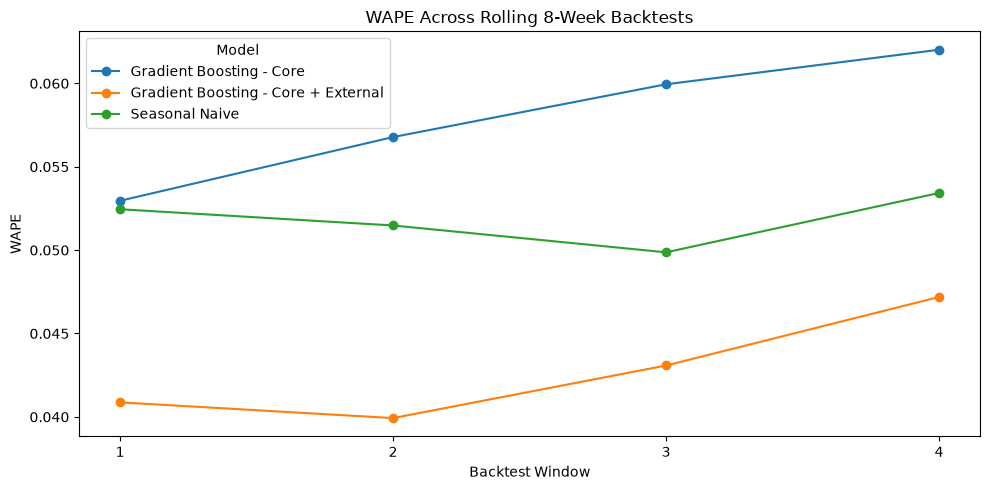

In [25]:
wape_plot = (
    backtest_comparison
    .pivot(
        index="Window",
        columns="Model",
        values="WAPE"
    )
)

wape_plot.plot(
    marker="o",
    figsize=(10, 5)
)

plt.title("WAPE Across Rolling 8-Week Backtests")
plt.xlabel("Backtest Window")
plt.ylabel("WAPE")
plt.xticks(
    sorted(
        backtest_comparison["Window"].unique()
    )
)
plt.tight_layout()
plt.show()

## Store-Level Forecast Error

Store-level WAPE identifies locations where the selected development model performs relatively poorly.

This is a diagnostic view and does not replace the aggregate model evaluation.

In [26]:
selected_store_results = []

if selected_model_name == "Gradient Boosting - Core + External":
    selected_numeric_features = external_numeric_features
    selected_categorical_features = external_categorical_features
    selected_feature_columns = external_feature_columns
else:
    selected_numeric_features = core_numeric_features
    selected_categorical_features = core_categorical_features
    selected_feature_columns = core_feature_columns


for window in backtest_windows:

    history = model_data[
        model_data["Date"] <= window["origin"]
    ].copy()

    training_data = history[
        [target, *selected_feature_columns]
    ].dropna(subset=[target])

    model = build_model(
        selected_numeric_features,
        selected_categorical_features
    )

    model.fit(
        training_data[selected_feature_columns],
        training_data[target]
    )

    future_calendar = calendar_data[
        calendar_data["Date"].between(
            window["start"],
            window["end"]
        )
    ].copy()

    forecast = recursive_backtest_forecast(
        model,
        history,
        future_calendar,
        selected_feature_columns
    )

    actual = model_data[
        model_data["Date"].between(
            window["start"],
            window["end"]
        )
    ][
        ["Store", "Date", "Weekly_Sales"]
    ]

    evaluation = forecast.merge(
        actual,
        on=["Store", "Date"],
        how="left",
        validate="one_to_one"
    )

    assert len(evaluation) == 360
    assert evaluation["Weekly_Sales"].notna().all()

    evaluation["Absolute_Error"] = (
        evaluation["Weekly_Sales"]
        - evaluation["Forecast"]
    ).abs()

    evaluation["Window"] = window["window"]

    selected_store_results.append(evaluation)


print("Store-level backtest completed.")

Store-level backtest completed.


In [27]:
store_backtest = pd.concat(
    selected_store_results,
    ignore_index=True
)

store_error_summary = (
    store_backtest
    .groupby("Store")
    .agg(
        Actual_Sales=(
            "Weekly_Sales",
            "sum"
        ),
        Absolute_Error=(
            "Absolute_Error",
            "sum"
        )
    )
)

store_error_summary["WAPE"] = (
    store_error_summary["Absolute_Error"]
    / store_error_summary["Actual_Sales"]
)

store_error_summary = (
    store_error_summary
    .sort_values(
        "WAPE",
        ascending=False
    )
)

store_error_summary.head(10)

,Actual_Sales,Absolute_Error,WAPE
Store,,,
14,56104525.72,7.011581e+06,0.124974
21,22515097.84,1.852153e+06,0.082263
31,44606129.21,2.909840e+06,0.065234
28,40142229.51,2.575659e+06,0.064163
19,45146524.63,2.698827e+06,0.059779
16,17722069.59,9.774486e+05,0.055154
7,20449638.46,1.127374e+06,0.055129
18,33944509.23,1.809916e+06,0.053320
15,19578649.03,1.003024e+06,0.051230


In [28]:
store_level_error = store_backtest[
    [
        "Store",
        "Date",
        "Forecast",
        "Weekly_Sales",
        "Absolute_Error",
        "Window"
    ]
].copy()

store_level_error["WAPE"] = (
    store_level_error["Absolute_Error"]
    / store_level_error["Weekly_Sales"].abs()
)

store_level_error = store_level_error.sort_values(
    ["Store", "Date"]
).reset_index(drop=True)

assert len(store_level_error) == 1440
assert store_level_error["Store"].nunique() == 45
assert not store_level_error.duplicated(
    ["Store", "Date", "Window"]
).any()

store_level_error.to_csv(
    PROCESSED_DIR / "store_level_error.csv",
    index=False
)

print("Saved store_level_error.csv")
print("Rows:", len(store_level_error))

Saved store_level_error.csv
Rows: 1440


## Backtest Findings

In [29]:
best_model = (
    average_performance
    .index[0]
)

best_wape = (
    average_performance
    .loc[best_model, "WAPE"]
)

print(
    f"Best average WAPE: {best_wape:.2%}"
)

print(
    f"Selected model: {best_model}"
)

Best average WAPE: 4.28%
Selected model: Gradient Boosting - Core + External


## Key Findings

- Rolling evaluation uses an 8-week recursive forecasting horizon.
- Each backtest trains only on information available before its forecast origin.
- Seasonal Naive provides a consistent year-over-year benchmark.
- Gradient Boosting is evaluated under the same forecasting horizon as the baseline.
- External variables are tested rather than assumed to improve performance.
- Average WAPE and window-to-window stability are used for development model selection.
- The final holdout remains untouched and is evaluated only in `07_final_forecast_and_business_insights.ipynb`.

In [30]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

backtest_comparison.to_csv(
    reports_dir / "model_evaluation_summary.csv",
    index=False
)

print("Saved model_evaluation_summary.csv")

Saved model_evaluation_summary.csv


In [31]:
store_error_summary = pd.concat(
    selected_store_results,
    ignore_index=True
)

store_error_summary.to_csv(
    reports_dir / "store_error_summary.csv",
    index=False
)

print("Saved store_error_summary.csv")

Saved store_error_summary.csv
